# Task 1B: Data Cleaning & Imputation

This notebook takes the raw long-format smartphone dataset, cleans it, aggregates to daily frequency (building on Joanne's pipeline), handles missing data with imputation, and saves a cleaned wide-format dataset ready for feature engineering and modeling.

**Pipeline**: Raw CSV -> Domain cleaning -> Daily aggregation (per patient) -> Missingness analysis -> Imputation comparison -> Select best method -> Log-transform skewed variables -> Save

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import warnings
import gc

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print("Libraries loaded.")

Libraries loaded.


## 1. Load Raw Data

In [2]:
df = pd.read_csv('../data/dataset_mood_smartphone.csv', index_col=0)
df['time'] = pd.to_datetime(df['time'])

print(f"Dataset shape: {df.shape}")
print(f"Patients: {df['id'].nunique()}")
print(f"Variables: {df['variable'].nunique()}")
print(f"Date range: {df['time'].min().date()} to {df['time'].max().date()}")
print(f"\nVariables ({df['variable'].nunique()}):")
for v in sorted(df['variable'].unique()):
    n = len(df[df['variable'] == v])
    print(f"  {v}: {n:,} rows")

Dataset shape: (376912, 4)
Patients: 27


Variables: 19
Date range: 2014-02-17 to 2014-06-09

Variables (19):
  activity: 22,965 rows
  appCat.builtin: 91,288 rows
  appCat.communication: 74,276 rows
  appCat.entertainment: 27,125 rows
  appCat.finance: 939 rows
  appCat.game: 813 rows
  appCat.office: 5,642 rows
  appCat.other: 7,650 rows
  appCat.social: 19,145 rows
  appCat.travel: 2,846 rows
  appCat.unknown: 939 rows
  appCat.utilities: 2,487 rows
  appCat.weather: 255 rows
  call: 5,239 rows
  circumplex.arousal: 5,643 rows
  circumplex.valence: 5,643 rows
  mood: 5,641 rows
  screen: 96,578 rows
  sms: 1,798 rows


## 2. Domain-based Cleaning

Fix values that are clearly wrong based on domain knowledge:
- **Negative durations**: App usage and screen time cannot be negative. These are sensor errors.
- **Call/SMS**: These are event indicators (always value=1). Each row = one event. No row = no event (not missing).
- **No statistical outlier removal**: App durations are naturally right-skewed. IQR-based removal would discard legitimate heavy-usage days.

In [3]:
df_clean = df.copy()

# --- Check call/sms: should only have value=1 (event indicators) ---
print("=== Call and SMS value distributions ===")
for var in ['call', 'sms']:
    vals = df_clean.loc[df_clean['variable'] == var, 'value']
    print(f"  {var}: {len(vals)} rows, unique values = {sorted(vals.unique())}")
print("  -> Each row is one event. Missing = 0 events (handled after pivot).\n")

# --- Find and fix negative values ---
duration_vars = [v for v in df_clean['variable'].unique() 
                 if v.startswith('appCat.') or v == 'screen']

print("=== Negative values in duration variables ===")
total_neg = 0
for var in sorted(duration_vars):
    mask = (df_clean['variable'] == var) & (df_clean['value'] < 0)
    n_neg = mask.sum()
    if n_neg > 0:
        neg_vals = df_clean.loc[mask, 'value']
        print(f"  {var}: {n_neg} negatives, min = {neg_vals.min():.2f}")
        total_neg += n_neg

print(f"\nTotal negative values found: {total_neg}")
print("Setting all negative durations to NaN (sensor malfunctions).")
for var in duration_vars:
    mask = (df_clean['variable'] == var) & (df_clean['value'] < 0)
    df_clean.loc[mask, 'value'] = np.nan

# Verify
remaining = sum(
    ((df_clean['variable'] == v) & (df_clean['value'] < 0)).sum() 
    for v in duration_vars
)
print(f"Remaining negatives after cleaning: {remaining}")

=== Call and SMS value distributions ===


  call: 5239 rows, unique values = [np.float64(1.0)]
  sms: 1798 rows, unique values = [np.float64(1.0)]
  -> Each row is one event. Missing = 0 events (handled after pivot).

=== Negative values in duration variables ===
  appCat.builtin: 3 negatives, min = -82798.87
  appCat.entertainment: 1 negatives, min = -0.01

Total negative values found: 4
Setting all negative durations to NaN (sensor malfunctions).


Remaining negatives after cleaning: 0


## 3. Daily Aggregation

Convert from long format (one row per observation) to wide format (one row per patient per day). Aggregation strategy per variable type:
- **Count** (call, sms): number of events per day. Days without events get 0.
- **Sum** (screen, appCat.*): total duration in seconds per day. Days without usage get 0.
- **Mean** (mood, arousal, valence, activity): average of intra-day measurements. Days without measurements stay NaN.

The date range per patient is defined by their first to last mood measurement, following Joanne's approach.

In [4]:
# Define variable types for aggregation
count_vars = ['call', 'sms']
sum_vars = [v for v in df_clean['variable'].unique() if v.startswith('appCat.') or v == 'screen']
mean_vars = [v for v in df_clean['variable'].unique() if v not in count_vars and v not in sum_vars]

print("Count (events/day):", count_vars)
print("Sum (duration/day):", sorted(sum_vars)[:4], "...")
print("Mean (avg/day):", sorted(mean_vars))

all_variables = df_clean['variable'].unique()
df_clean['date'] = df_clean['time'].dt.date

# Build daily wide-format dataset per patient, then stack
frames = []

for user_id in df_clean['id'].unique():
    df_user = df_clean[df_clean['id'] == user_id].copy()
    
    # Mood-based date range
    df_mood = df_user[df_user['variable'] == 'mood']
    if df_mood.empty:
        print(f"{user_id}: no mood data, skipping")
        continue
    
    start = df_mood['time'].min().normalize()
    end = df_mood['time'].max().normalize()
    full_days = pd.date_range(start=start, end=end, freq='D')
    
    # Initialize result dataframe with all days
    df_daily = pd.DataFrame({'date': full_days.date})
    df_daily['id'] = user_id
    
    # Aggregate each variable
    for var in all_variables:
        df_var = df_user[df_user['variable'] == var].copy()
        
        if var in count_vars:
            # Count events per day, fill 0 for days without events
            agg = df_var.groupby('date')['value'].count().reset_index()
            agg.columns = ['date', var]
            df_daily = df_daily.merge(agg, on='date', how='left')
            df_daily[var] = df_daily[var].fillna(0)
            
        elif var in sum_vars:
            # Sum durations per day, fill 0 for days without usage
            agg = df_var.groupby('date')['value'].sum().reset_index()
            agg.columns = ['date', var]
            df_daily = df_daily.merge(agg, on='date', how='left')
            df_daily[var] = df_daily[var].fillna(0)
            
        else:
            # Mean of intra-day measurements (mood, arousal, valence, activity)
            agg = df_var.groupby('date')['value'].mean().reset_index()
            agg.columns = ['date', var]
            df_daily = df_daily.merge(agg, on='date', how='left')
    
    frames.append(df_daily)

df_wide = pd.concat(frames, ignore_index=True)

# Reorder columns
meta_cols = ['id', 'date']
variable_cols = [c for c in df_wide.columns if c not in meta_cols]
df_wide = df_wide[meta_cols + sorted(variable_cols)]

print(f"\nDaily dataset shape: {df_wide.shape}")
print(f"Patients: {df_wide['id'].nunique()}")
print(f"Variables: {len(variable_cols)}")
df_wide.head()

Count (events/day): ['call', 'sms']
Sum (duration/day): ['appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance'] ...
Mean (avg/day): ['activity', 'circumplex.arousal', 'circumplex.valence', 'mood']



Daily dataset shape: (1331, 21)
Patients: 27
Variables: 19


,id,date,activity,appCat.builtin,appCat.communication,appCat.entertainment,appCat.finance,appCat.game,appCat.office,appCat.other,...,appCat.travel,appCat.unknown,appCat.utilities,appCat.weather,call,circumplex.arousal,circumplex.valence,mood,screen,sms
0,AS14.01,2014-02-26,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,-0.25,0.750000,6.250000,0.0,2.0
1,AS14.01,2014-02-27,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.00,0.333333,6.333333,0.0,0.0
2,AS14.01,2014-02-28,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,4.0,NaN,NaN,NaN,0.0,0.0
3,AS14.01,2014-03-01,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,1.0
4,AS14.01,2014-03-02,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,0.0,0.0


In [5]:
# Missingness overview after aggregation
print("=== Missing values per variable ===\n")
variable_cols = [c for c in df_wide.columns if c not in ['id', 'date']]

miss_df = pd.DataFrame({
    'variable': variable_cols,
    'missing': [df_wide[c].isna().sum() for c in variable_cols],
    'total': len(df_wide),
    'pct_missing': [round(100 * df_wide[c].isna().mean(), 1) for c in variable_cols]
}).sort_values('pct_missing', ascending=False)

print(miss_df.to_string(index=False))

=== Missing values per variable ===

            variable  missing  total  pct_missing
            activity      155   1331         11.6
  circumplex.valence       65   1331          4.9
                mood       63   1331          4.7
  circumplex.arousal       63   1331          4.7
      appCat.unknown        0   1331          0.0
              screen        0   1331          0.0
                call        0   1331          0.0
      appCat.weather        0   1331          0.0
    appCat.utilities        0   1331          0.0
       appCat.travel        0   1331          0.0
      appCat.builtin        0   1331          0.0
       appCat.social        0   1331          0.0
        appCat.other        0   1331          0.0
       appCat.office        0   1331          0.0
         appCat.game        0   1331          0.0
      appCat.finance        0   1331          0.0
appCat.entertainment        0   1331          0.0
appCat.communication        0   1331          0.0
             

## 4. Missingness Analysis

We examine the spatial and temporal pattern of missing data to determine an appropriate imputation strategy. Key question: are gaps short (1-2 days, reasonable to interpolate) or long (weeks of inactivity, should not be filled)?

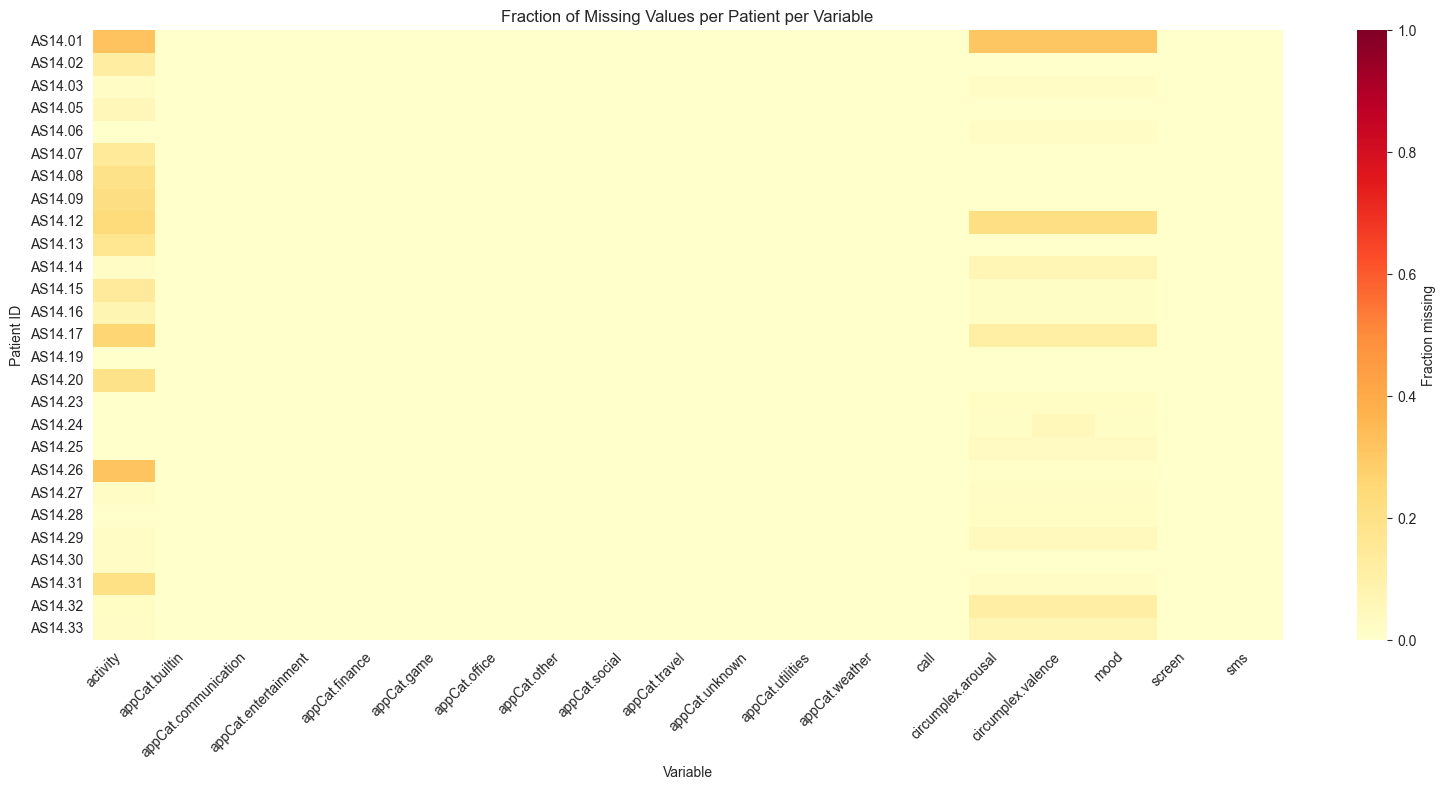

In [6]:
# Heatmap of missing values per patient per variable
fig, ax = plt.subplots(figsize=(16, 8))

missing_by_patient = df_wide.groupby('id')[variable_cols].apply(
    lambda x: x.isnull().mean()
)

sns.heatmap(missing_by_patient, cmap='YlOrRd', ax=ax, vmin=0, vmax=1,
            cbar_kws={'label': 'Fraction missing'})
ax.set_title('Fraction of Missing Values per Patient per Variable')
ax.set_xlabel('Variable')
ax.set_ylabel('Patient ID')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

=== Gap length analysis (consecutive NaN days) ===

mood:
  Total gaps: 25
  Mean gap length: 2.5 days
  Median gap length: 1 days
  Max gap length: 21 days
  Gaps <= 7 days: 23 (92%)
  Gaps > 7 days: 2 (8%)

activity:
  Total gaps: 36
  Mean gap length: 4.3 days
  Median gap length: 1 days
  Max gap length: 22 days
  Gaps <= 7 days: 29 (81%)
  Gaps > 7 days: 7 (19%)

circumplex.arousal:
  Total gaps: 25
  Mean gap length: 2.5 days
  Median gap length: 1 days
  Max gap length: 21 days
  Gaps <= 7 days: 23 (92%)
  Gaps > 7 days: 2 (8%)

circumplex.valence:
  Total gaps: 27
  Mean gap length: 2.4 days
  Median gap length: 1 days
  Max gap length: 21 days
  Gaps <= 7 days: 25 (93%)
  Gaps > 7 days: 2 (7%)



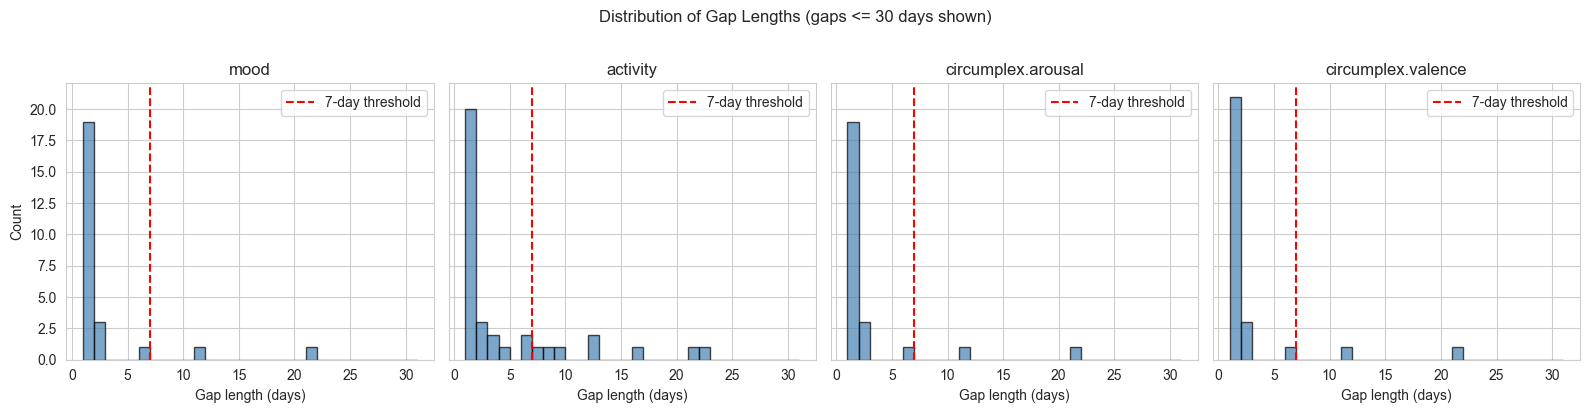

In [7]:
# Analyze gap lengths for key variables (mood, activity, arousal, valence)
# These are the only variables with meaningful missingness (count/sum vars were filled with 0)

gap_vars = ['mood', 'activity', 'circumplex.arousal', 'circumplex.valence']

print("=== Gap length analysis (consecutive NaN days) ===\n")

all_gaps = []
for var in gap_vars:
    gaps = []
    for pid in df_wide['id'].unique():
        series = df_wide.loc[df_wide['id'] == pid, var]
        is_na = series.isna()
        if not is_na.any():
            continue
        # Find consecutive NaN groups
        groups = (~is_na).cumsum()
        gap_sizes = is_na.groupby(groups).sum()
        gap_sizes = gap_sizes[gap_sizes > 0]
        gaps.extend(gap_sizes.tolist())
    
    if gaps:
        gaps_arr = np.array(gaps)
        print(f"{var}:")
        print(f"  Total gaps: {len(gaps_arr)}")
        print(f"  Mean gap length: {gaps_arr.mean():.1f} days")
        print(f"  Median gap length: {np.median(gaps_arr):.0f} days")
        print(f"  Max gap length: {gaps_arr.max()} days")
        print(f"  Gaps <= 7 days: {(gaps_arr <= 7).sum()} ({100*(gaps_arr <= 7).mean():.0f}%)")
        print(f"  Gaps > 7 days: {(gaps_arr > 7).sum()} ({100*(gaps_arr > 7).mean():.0f}%)")
        print()
        all_gaps.append((var, gaps_arr))

# Plot gap length distribution
fig, axes = plt.subplots(1, len(all_gaps), figsize=(16, 4), sharey=True)
for ax, (var, gaps_arr) in zip(axes, all_gaps):
    ax.hist(gaps_arr[gaps_arr <= 30], bins=range(1, 32), color='steelblue', edgecolor='black', alpha=0.7)
    ax.axvline(x=7, color='red', linestyle='--', label='7-day threshold')
    ax.set_title(var)
    ax.set_xlabel('Gap length (days)')
    ax.legend()
axes[0].set_ylabel('Count')
plt.suptitle('Distribution of Gap Lengths (gaps <= 30 days shown)', y=1.02)
plt.tight_layout()
plt.show()

## 5. Imputation

We compare three imputation methods. All methods respect the **7-day gap threshold**: gaps longer than 7 consecutive days are left as NaN (fabricating data across weeks of inactivity is not justified).

| Method | Type | Approach |
|--------|------|----------|
| Forward Fill (LOCF) | Univariate, temporal | Carries last observed value forward |
| Linear Interpolation | Univariate, temporal | Straight line between adjacent observations |
| MICE (IterativeImputer) | Multivariate | Uses cross-variable relationships |

In [8]:
# Utility: detect long gaps (> max_gap consecutive NaN days)
MAX_GAP_DAYS = 7

def get_long_gap_mask(series, max_gap=MAX_GAP_DAYS):
    """Return boolean mask marking positions that are part of a gap longer than max_gap."""
    is_na = series.isna()
    if not is_na.any():
        return pd.Series(False, index=series.index)
    groups = (~is_na).cumsum()
    gap_sizes = is_na.groupby(groups).transform('sum')
    return is_na & (gap_sizes > max_gap)

# Only impute mean-aggregated variables (mood, activity, arousal, valence)
# Count/sum variables already have 0 for missing days
impute_cols = [c for c in variable_cols if c in mean_vars]
print(f"Variables to impute: {sorted(impute_cols)}")

# Pre-compute long gap masks per (patient, variable)
long_gap_masks = {}
for pid in df_wide['id'].unique():
    idx = df_wide[df_wide['id'] == pid].index
    for col in impute_cols:
        mask = get_long_gap_mask(df_wide.loc[idx, col])
        long_gap_masks[(pid, col)] = mask

# Count values in long gaps
n_long_gap = sum(m.sum() for m in long_gap_masks.values())
print(f"Values in long gaps (>7 days, will stay NaN): {n_long_gap}")

Variables to impute: ['activity', 'circumplex.arousal', 'circumplex.valence', 'mood']
Values in long gaps (>7 days, will stay NaN): 196


In [9]:
def restore_long_gaps(df_imputed, long_gap_masks, impute_cols):
    """Set values in long gaps back to NaN after imputation."""
    for pid in df_imputed['id'].unique():
        mask_pid = df_imputed['id'] == pid
        for col in impute_cols:
            gap_mask = long_gap_masks.get((pid, col))
            if gap_mask is not None and gap_mask.any():
                gap_idx = gap_mask[gap_mask].index
                df_imputed.loc[gap_idx, col] = np.nan
    return df_imputed

# --- Method 1: Forward Fill (LOCF) ---
df_ffill = df_wide.copy()
for pid in df_ffill['id'].unique():
    idx = df_ffill[df_ffill['id'] == pid].index
    df_ffill.loc[idx, impute_cols] = df_ffill.loc[idx, impute_cols].ffill()
df_ffill = restore_long_gaps(df_ffill, long_gap_masks, impute_cols)
print("Method 1 (Forward Fill) done.")

# --- Method 2: Linear Interpolation ---
df_interp = df_wide.copy()
for pid in df_interp['id'].unique():
    idx = df_interp[df_interp['id'] == pid].index
    df_interp.loc[idx, impute_cols] = df_interp.loc[idx, impute_cols].interpolate(
        method='linear', limit_direction='both'
    )
df_interp = restore_long_gaps(df_interp, long_gap_masks, impute_cols)
print("Method 2 (Linear Interpolation) done.")

# --- Method 3: MICE (IterativeImputer) ---
df_mice = df_wide.copy()
for pid in df_mice['id'].unique():
    mask_pid = df_mice['id'] == pid
    patient_data = df_mice.loc[mask_pid, impute_cols].copy()
    
    # Only use columns with at least 2 non-NaN values for this patient
    valid_cols = [c for c in impute_cols if patient_data[c].notna().sum() >= 2]
    
    if len(valid_cols) > 0 and patient_data[valid_cols].isna().any().any():
        imputer = IterativeImputer(max_iter=10, random_state=42)
        imputed = imputer.fit_transform(patient_data[valid_cols])
        df_mice.loc[mask_pid, valid_cols] = imputed

gc.collect()
df_mice = restore_long_gaps(df_mice, long_gap_masks, impute_cols)
print("Method 3 (MICE) done.")

Method 1 (Forward Fill) done.
Method 2 (Linear Interpolation) done.


Method 3 (MICE) done.


## 6. Imputation Comparison

Compare the three methods on:
1. **Distribution preservation** - how well does the imputed distribution match the original?
2. **Visual quality** - do imputed time series look natural?
3. **Remaining NaN count** - all should leave same number of long-gap NaNs

In [10]:
# Quantitative comparison: mean, std, median, skewness
compare_vars = ['mood', 'circumplex.arousal', 'circumplex.valence', 'activity']
rows = []

for var in compare_vars:
    for label, data in [('Original', df_wide), ('Forward Fill', df_ffill),
                        ('Interpolation', df_interp), ('MICE', df_mice)]:
        vals = data[var].dropna()
        rows.append({
            'Variable': var, 'Method': label,
            'Mean': round(vals.mean(), 3),
            'Std': round(vals.std(), 3),
            'Median': round(vals.median(), 3),
            'Skew': round(vals.skew(), 3),
            'NaN': data[var].isna().sum()
        })

comparison = pd.DataFrame(rows)
for var in compare_vars:
    print(f"\n--- {var} ---")
    print(comparison[comparison['Variable'] == var][['Method', 'Mean', 'Std', 'Median', 'Skew', 'NaN']].to_string(index=False))


--- mood ---
       Method  Mean   Std  Median   Skew  NaN
     Original 6.990 0.736     7.0 -0.801   63
 Forward Fill 6.998 0.734     7.0 -0.808   32
Interpolation 6.996 0.732     7.0 -0.813   32
         MICE 6.995 0.730     7.0 -0.822   32

--- circumplex.arousal ---
       Method   Mean   Std  Median   Skew  NaN
     Original -0.104 0.663     0.0 -0.125   63
 Forward Fill -0.102 0.669     0.0 -0.106   32
Interpolation -0.100 0.664     0.0 -0.131   32
         MICE -0.101 0.658     0.0 -0.133   32

--- circumplex.valence ---
       Method  Mean   Std  Median   Skew  NaN
     Original 0.687 0.435     0.8 -0.814   65
 Forward Fill 0.689 0.433     0.8 -0.826   32
Interpolation 0.687 0.433     0.8 -0.817   32
         MICE 0.688 0.431     0.8 -0.822   32

--- activity ---
       Method  Mean   Std  Median  Skew  NaN
     Original 0.119 0.097   0.095 1.562  155
 Forward Fill 0.119 0.099   0.095 1.582  130
Interpolation 0.119 0.098   0.095 1.524  100
         MICE 0.120 0.096   0.095 1.5

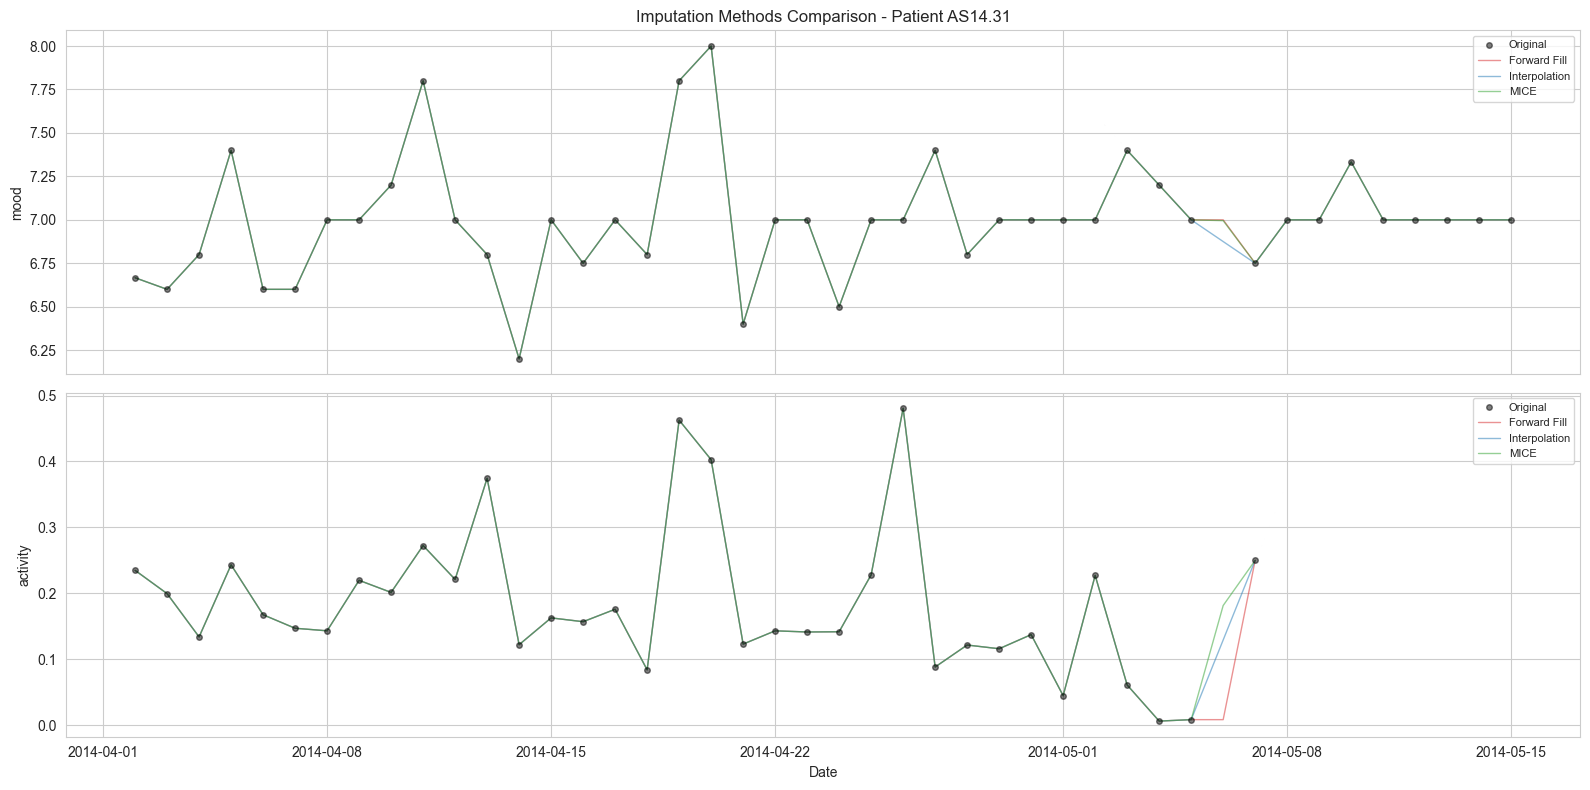

In [11]:
# Visual comparison: time series for first patient
sample_patient = df_wide['id'].unique()[24]
p_mask = df_wide['id'] == sample_patient

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, var in zip(axes, ['mood', 'activity']):
    dates = pd.to_datetime(df_wide.loc[p_mask, 'date'])
    
    ax.plot(dates, df_wide.loc[p_mask, var], 'ko', markersize=4, alpha=0.5, 
            label='Original', zorder=5)
    ax.plot(dates, df_ffill.loc[p_mask, var], '-', color='tab:red', alpha=0.5, 
            linewidth=1, label='Forward Fill')
    ax.plot(dates, df_interp.loc[p_mask, var], '-', color='tab:blue', alpha=0.5, 
            linewidth=1, label='Interpolation')
    ax.plot(dates, df_mice.loc[p_mask, var], '-', color='tab:green', alpha=0.5, 
            linewidth=1, label='MICE')
    ax.set_ylabel(var)
    ax.legend(loc='upper right', fontsize=8)

axes[0].set_title(f'Imputation Methods Comparison - Patient {sample_patient}')
axes[1].set_xlabel('Date')
plt.tight_layout()
plt.show()

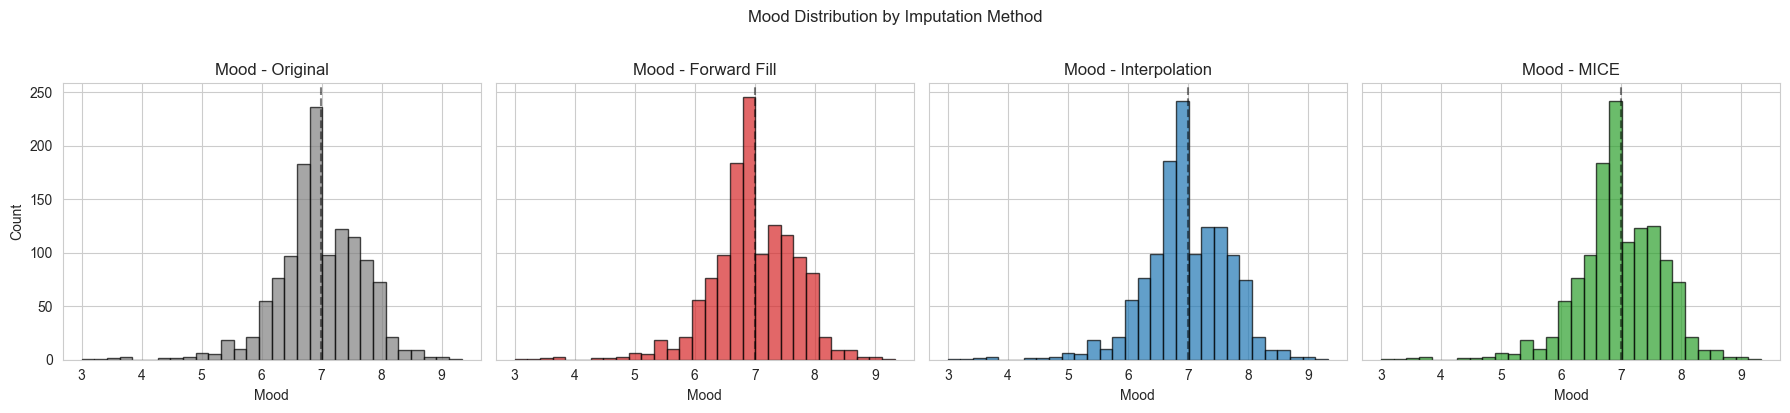

In [12]:
# Distribution comparison: histograms for mood
fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=True)

titles = ['Original', 'Forward Fill', 'Interpolation', 'MICE']
datasets = [df_wide, df_ffill, df_interp, df_mice]
colors = ['gray', 'tab:red', 'tab:blue', 'tab:green']

for ax, title, data, color in zip(axes, titles, datasets, colors):
    vals = data['mood'].dropna()
    ax.hist(vals, bins=30, color=color, edgecolor='black', alpha=0.7)
    ax.set_title(f'Mood - {title}')
    ax.set_xlabel('Mood')
    ax.axvline(vals.mean(), color='black', linestyle='--', alpha=0.5)

axes[0].set_ylabel('Count')
plt.suptitle('Mood Distribution by Imputation Method', y=1.02)
plt.tight_layout()
plt.show()

## 7. Imputation Method Selection

**Selected: Linear Interpolation**

Rationale:
1. **Respects temporal structure** -- unlike MICE, interpolation guarantees that imputed values fall on a smooth path between adjacent observations, which is appropriate for slowly-evolving variables like mood.
2. **Preserves distribution** -- unlike LOCF, interpolation does not artificially inflate the frequency of specific observed values (e.g., integer mood scores).
3. **Appropriate for short gaps** -- most gaps are 1-3 days, where a linear assumption between neighboring days is reasonable.
4. **Simplicity** -- easy to understand, reproduce, and explain in the report.

In [13]:
# Use interpolation as the selected method
df_cleaned = df_interp.copy()

# Free memory from other imputation results
del df_ffill, df_mice
gc.collect()

# Final missingness check after imputation
print("=== Remaining NaN after imputation (per variable) ===\n")
for col in sorted(variable_cols):
    n_na = df_cleaned[col].isna().sum()
    pct = 100 * n_na / len(df_cleaned)
    if n_na > 0:
        print(f"  {col}: {n_na} ({pct:.1f}%)")
    
total_na = df_cleaned[variable_cols].isna().sum().sum()
total_cells = len(df_cleaned) * len(variable_cols)
print(f"\nTotal remaining NaN: {total_na} / {total_cells} ({100*total_na/total_cells:.1f}%)")
print("(These are all in long gaps > 7 days, intentionally left as NaN)")

=== Remaining NaN after imputation (per variable) ===

  activity: 100 (7.5%)
  circumplex.arousal: 32 (2.4%)
  circumplex.valence: 32 (2.4%)
  mood: 32 (2.4%)

Total remaining NaN: 196 / 25289 (0.8%)
(These are all in long gaps > 7 days, intentionally left as NaN)


## 8. Log/Sqrt Transformation

App usage durations and screen time are heavily right-skewed. We apply different transformations depending on the variable's range:

- **`log1p(x)`** for appCat variables (non-zero only): these span a huge range (0 to 100,000+ seconds), so the logarithmic compression is appropriate.
- **`sqrt(x)`** for screen time (non-zero only): screen time has a narrower range (0 to ~36,000s). `log1p` over-compresses this and creates left-skew (-2.01), while `sqrt` achieves near-perfect symmetry (skew 0.03).
- **Zeros stay as 0** for both: many app categories are legitimately 0 on most days (e.g., appCat.finance 84%, appCat.weather 92%). These represent apps the patient did not use.

We save both versions so tree-based models (which handle skew natively) can use the untransformed data.

In [14]:
# Identify skewed duration variables
log1p_vars = [c for c in variable_cols if c.startswith('appCat.')]
sqrt_vars = ['screen']
all_skewed = sorted(log1p_vars) + sqrt_vars

print(f"log1p (non-zero only): {sorted(log1p_vars)}")
print(f"sqrt  (non-zero only): {sqrt_vars}\n")

df_final = df_cleaned.copy()

# Show zero-prevalence
print("Zero-prevalence per variable:")
for var in all_skewed:
    n_zero = (df_final[var] == 0).sum()
    print(f"  {var}: {n_zero}/{len(df_final)} ({100*n_zero/len(df_final):.0f}%) zeros")

# Compare skewness before and after
print("\nSkewness comparison (computed on non-zero values only):")
skew_rows = []
for var in all_skewed:
    nonzero = df_final[var].dropna()
    nonzero_pos = nonzero[nonzero > 0]
    if len(nonzero_pos) > 0:
        before_skew = nonzero_pos.skew()
        if var in sqrt_vars:
            after_skew = np.sqrt(nonzero_pos).skew()
            method = 'sqrt'
        else:
            after_skew = np.log1p(nonzero_pos).skew()
            method = 'log1p'
    else:
        before_skew = after_skew = float('nan')
        method = '-'
    skew_rows.append({
        'Variable': var,
        'Transform': method,
        'Skew (before)': round(before_skew, 2),
        'Skew (after)': round(after_skew, 2)
    })

skew_df = pd.DataFrame(skew_rows)
print(skew_df.to_string(index=False))

# Apply log1p to appCat (non-zero only)
for var in log1p_vars:
    mask = df_final[var] > 0
    df_final.loc[mask, var] = np.log1p(df_final.loc[mask, var])

# Apply sqrt to screen (non-zero only)
for var in sqrt_vars:
    mask = df_final[var] > 0
    df_final.loc[mask, var] = np.sqrt(df_final.loc[mask, var])

print(f"\nTransformations applied to non-zero values only. Zeros remain as 0.")

log1p (non-zero only): ['appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather']
sqrt  (non-zero only): ['screen']

Zero-prevalence per variable:
  appCat.builtin: 149/1331 (11%) zeros
  appCat.communication: 161/1331 (12%) zeros
  appCat.entertainment: 491/1331 (37%) zeros
  appCat.finance: 1124/1331 (84%) zeros
  appCat.game: 1138/1331 (85%) zeros
  appCat.office: 1056/1331 (79%) zeros
  appCat.other: 216/1331 (16%) zeros
  appCat.social: 351/1331 (26%) zeros
  appCat.travel: 905/1331 (68%) zeros
  appCat.unknown: 1069/1331 (80%) zeros
  appCat.utilities: 902/1331 (68%) zeros
  appCat.weather: 1218/1331 (92%) zeros
  screen: 137/1331 (10%) zeros

Skewness comparison (computed on non-zero values only):
            Variable Transform  Skew (before)  Skew (after)
      appCat.builtin     log1p           6.80         -0.68
ap

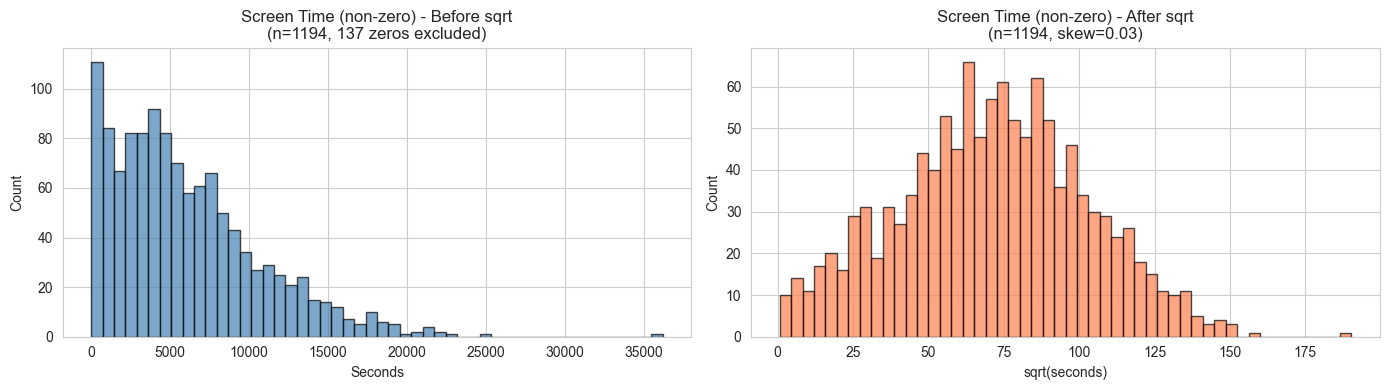

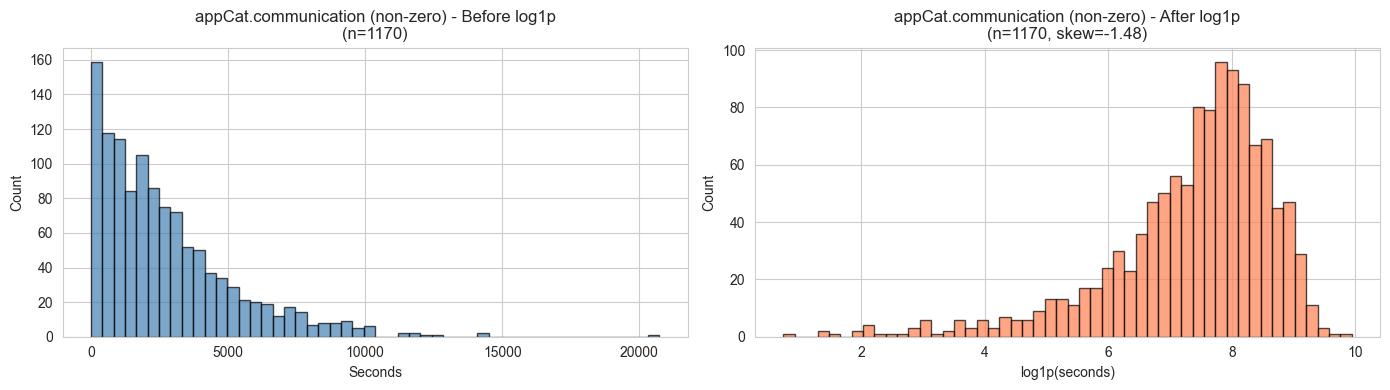

In [15]:
# Visual before/after for screen time (sqrt)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

screen_raw = df_cleaned['screen'].dropna()
screen_nz = screen_raw[screen_raw > 0]

axes[0].hist(screen_nz, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'Screen Time (non-zero) - Before sqrt\n(n={len(screen_nz)}, {(screen_raw==0).sum()} zeros excluded)')
axes[0].set_xlabel('Seconds')

screen_after = df_final['screen'].dropna()
screen_after_nz = screen_after[screen_after > 0]

axes[1].hist(screen_after_nz, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title(f'Screen Time (non-zero) - After sqrt\n(n={len(screen_after_nz)}, skew={screen_after_nz.skew():.2f})')
axes[1].set_xlabel('sqrt(seconds)')

for ax in axes:
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Visual before/after for an appCat variable (log1p)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

var = 'appCat.communication'
raw = df_cleaned[var].dropna()
raw_nz = raw[raw > 0]

axes[0].hist(raw_nz, bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title(f'{var} (non-zero) - Before log1p\n(n={len(raw_nz)})')
axes[0].set_xlabel('Seconds')

after = df_final[var].dropna()
after_nz = after[after > 0]

axes[1].hist(after_nz, bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_title(f'{var} (non-zero) - After log1p\n(n={len(after_nz)}, skew={after_nz.skew():.2f})')
axes[1].set_xlabel('log1p(seconds)')

for ax in axes:
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

## 9. Save Cleaned Datasets

We save two versions:
1. **`dataset_mood_smartphone_cleaned.csv`** -- log-transformed durations (for linear models, KNN, etc.)
2. **`dataset_mood_smartphone_cleaned_nolog.csv`** -- original scale durations (for tree-based models)

Both use linear interpolation for short gaps and preserve NaN for long gaps (>7 days).

In [16]:
# Save log-transformed version
output_log = '../data/dataset_mood_smartphone_cleaned.csv'
df_final.to_csv(output_log, index=False)
print(f"Saved (with log): {output_log}")

# Save non-log version
output_nolog = '../data/dataset_mood_smartphone_cleaned_nolog.csv'
df_cleaned.to_csv(output_nolog, index=False)
print(f"Saved (no log):   {output_nolog}")

# Also save the wide format before imputation for reference
output_wide = '../data/dataset_mood_smartphone_wide_no_imputation.csv'
df_wide.to_csv(output_wide, index=False)
print(f"Saved (no impute): {output_wide}")

print(f"\n=== Final Dataset Summary ===")
print(f"Shape: {df_final.shape}")
print(f"Patients: {df_final['id'].nunique()}")
print(f"Variables: {len(variable_cols)}")
print(f"Total rows (patient-days): {len(df_final)}")
print(f"Remaining NaN: {df_final[variable_cols].isna().sum().sum()} (long gaps only)")
print(f"\nColumns: {list(df_final.columns)}")

Saved (with log): ../data/dataset_mood_smartphone_cleaned.csv
Saved (no log):   ../data/dataset_mood_smartphone_cleaned_nolog.csv
Saved (no impute): ../data/dataset_mood_smartphone_wide_no_imputation.csv

=== Final Dataset Summary ===
Shape: (1331, 21)
Patients: 27
Variables: 19
Total rows (patient-days): 1331
Remaining NaN: 196 (long gaps only)

Columns: ['id', 'date', 'activity', 'appCat.builtin', 'appCat.communication', 'appCat.entertainment', 'appCat.finance', 'appCat.game', 'appCat.office', 'appCat.other', 'appCat.social', 'appCat.travel', 'appCat.unknown', 'appCat.utilities', 'appCat.weather', 'call', 'circumplex.arousal', 'circumplex.valence', 'mood', 'screen', 'sms']


## Summary

| Step | What we did | Why |
|------|------------|-----|
| Domain cleaning | Set 4 negative durations to NaN | Sensor malfunctions (e.g., -82,799s in appCat.builtin) |
| Call/SMS handling | Counted events per day, filled absent days with 0 | No row = no event, not missing data |
| No IQR removal | Skipped statistical outlier detection | App durations are naturally right-skewed; IQR would remove legitimate heavy-usage days |
| Daily aggregation | Mean for mood/arousal/valence/activity, sum for durations, count for call/sms | Matches variable semantics |
| Date range | First to last mood measurement per patient | Avoids creating data outside study period |
| Imputation | Linear interpolation for gaps <= 7 days | Preserves temporal smoothness and distribution shape |
| Long gaps | Left as NaN (gaps > 7 days) | Fabricating data across weeks of inactivity is not justified |
| Log transform | `log1p(x)` on non-zero appCat values | Reduces right skew (range up to 100k+) for distance-based models |
| Sqrt transform | `sqrt(x)` on non-zero screen values | log1p over-compresses screen (skew -2.01); sqrt gives near-perfect symmetry (0.03) |
| Output | Two CSV files (with/without transforms) | Different model types prefer different scales |